# Загрузка библиотек

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import sys
import os
import numpy
import matplotlib.pyplot as plt
import shap
import featurewiz
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTENC
from sklearn.utils import class_weight

Imported 0.2.6 version. Select nrows to a small number when running on huge datasets.
output = featurewiz(dataname, target, corr_limit=0.90, verbose=2, sep=',', 
		header=0, test_data='',feature_engg='', category_encoders='',
		dask_xgboost_flag=False, nrows=None, skip_sulov=False)
Create new features via 'feature_engg' flag : ['interactions','groupby','target']



In [3]:
sys.path.append('../utils_functionality/')
from data_analysis.split_analisys import *
from data_analysis.reports import *
from models.class_models import *

In [4]:
pd.set_option('display.max_columns', None)

In [5]:
RANDOM_STATE = 42

# Загрузка данных и разделение на train, test

In [6]:
df = pd.read_excel('../data/df_merged_edited.xlsx', index_col=[0])
train, test = train_test_split(df, test_size=0.33, random_state=RANDOM_STATE)

# Моделирование

## Baseline 1. Featurewiz + XGBoost

### Splashing

In [7]:
cs = CreateSamples(df, train, test, target='splashing', use_featurewiz=True)
X_train, X_test, y_train, y_test = cs.get_samples()

############################################################################################
############       F A S T   F E A T U R E  E N G G    A N D    S E L E C T I O N ! ########
# Be judicious with featurewiz. Don't use it to create too many un-interpretable features! #
############################################################################################
featurewiz has selected 0.7 as the correlation limit. Change this limit to fit your needs...
Skipping feature engineering since no feature_engg input...
Skipping category encoding since no category encoders specified in input...
#### Single_Label Binary_Classification problem ####
    Loaded train data. Shape = (372, 24)
#### Single_Label Binary_Classification problem ####
No test data filename given...
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#############################################

In [8]:
model = XGBClassifier()
model.fit(X_train, y_train)
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
get_classification_report(y_train, y_test, y_preds, y_preds_proba)

,precision,recall,f1-score,support
0,0.850746,0.876923,0.863636,65.000000
1,0.857143,0.827586,0.842105,58.000000
accuracy,0.853659,0.853659,0.853659,0.853659
macro avg,0.853945,0.852255,0.852871,123.000000
weighted avg,0.853763,0.853659,0.853483,123.000000


#### Cross-Validation

In [9]:
get_cv_results(model, X_train, y_train, X_test, y_test)

F1 Train:	80.97% (std: 2.51%)
F1 Test:	79.55% (std: 5.16%)


#### SHAP interpretation

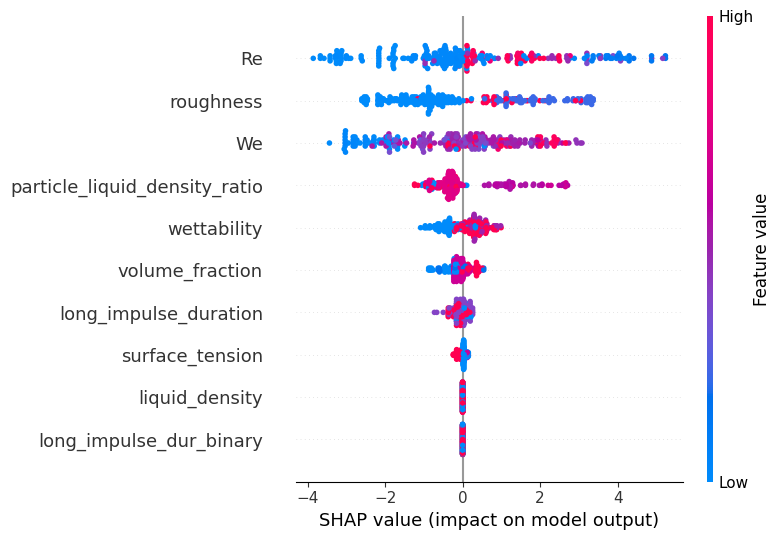

In [10]:
get_shap_interpretation(model, X_train)

#### Net impact

In [11]:
cs = CreateSamples(df, train, test, target='net_impact', use_featurewiz=True)
X_train, X_test, y_train, y_test = cs.get_samples()

############################################################################################
############       F A S T   F E A T U R E  E N G G    A N D    S E L E C T I O N ! ########
# Be judicious with featurewiz. Don't use it to create too many un-interpretable features! #
############################################################################################
featurewiz has selected 0.7 as the correlation limit. Change this limit to fit your needs...
Skipping feature engineering since no feature_engg input...
Skipping category encoding since no category encoders specified in input...
#### Single_Label Binary_Classification problem ####
    Loaded train data. Shape = (372, 24)
#### Single_Label Binary_Classification problem ####
No test data filename given...
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#############################################

In [12]:
model = XGBClassifier()
model.fit(X_train, y_train)
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
get_classification_report(y_train, y_test, y_preds, y_preds_proba)

,precision,recall,f1-score,support
0,0.857143,0.951220,0.901734,82.000000
1,0.875000,0.682927,0.767123,41.000000
accuracy,0.861789,0.861789,0.861789,0.861789
macro avg,0.866071,0.817073,0.834429,123.000000
weighted avg,0.863095,0.861789,0.856864,123.000000


In [13]:
get_cv_results(model, X_train, y_train, X_test, y_test)

F1 Train:	70.84% (std: 7.44%)
F1 Test:	77.88% (std: 11.39%)


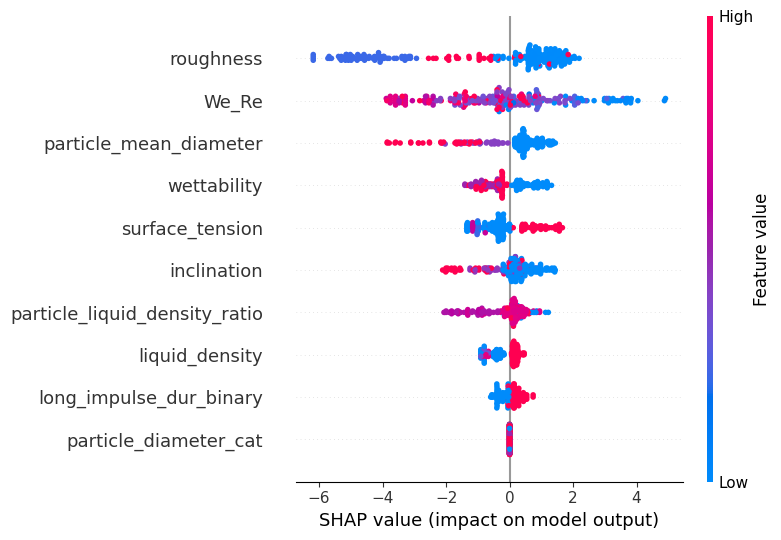

In [14]:
get_shap_interpretation(model, X_train)

## Baseline 2. Featurewiz + XGBoost

### Splashing

In [15]:
cs = CreateSamples(df, train, test, target='splashing', use_featurewiz=True)
X_train, X_test, y_train, y_test = cs.get_samples()

############################################################################################
############       F A S T   F E A T U R E  E N G G    A N D    S E L E C T I O N ! ########
# Be judicious with featurewiz. Don't use it to create too many un-interpretable features! #
############################################################################################
featurewiz has selected 0.7 as the correlation limit. Change this limit to fit your needs...
Skipping feature engineering since no feature_engg input...
Skipping category encoding since no category encoders specified in input...
#### Single_Label Binary_Classification problem ####
    Loaded train data. Shape = (372, 24)
#### Single_Label Binary_Classification problem ####
No test data filename given...
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#############################################

In [16]:
smote_nc = SMOTENC(categorical_features=[7], random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)

In [17]:
model = XGBClassifier()
model.fit(X_train, y_train)
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
get_classification_report(y_train, y_test, y_preds, y_preds_proba)

,precision,recall,f1-score,support
0,0.852941,0.892308,0.872180,65.000000
1,0.872727,0.827586,0.849558,58.000000
accuracy,0.861789,0.861789,0.861789,0.861789
macro avg,0.862834,0.859947,0.860869,123.000000
weighted avg,0.862271,0.861789,0.861513,123.000000


#### Cross-Validation

In [18]:
get_cv_results(model, X_train, y_train, X_test, y_test)

F1 Train:	84.66% (std: 4.54%)
F1 Test:	79.55% (std: 5.16%)


#### SHAP interpretation

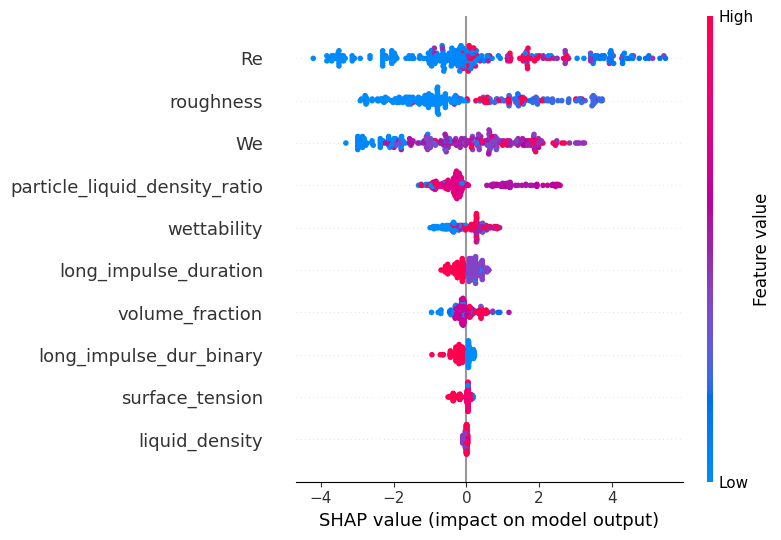

In [19]:
get_shap_interpretation(model, X_train)

### net_impact

In [20]:
cs = CreateSamples(df, train, test, target='net_impact', use_featurewiz=True)
X_train, X_test, y_train, y_test = cs.get_samples()

############################################################################################
############       F A S T   F E A T U R E  E N G G    A N D    S E L E C T I O N ! ########
# Be judicious with featurewiz. Don't use it to create too many un-interpretable features! #
############################################################################################
featurewiz has selected 0.7 as the correlation limit. Change this limit to fit your needs...
Skipping feature engineering since no feature_engg input...
Skipping category encoding since no category encoders specified in input...
#### Single_Label Binary_Classification problem ####
    Loaded train data. Shape = (372, 24)
#### Single_Label Binary_Classification problem ####
No test data filename given...
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#############################################

In [21]:
smote_nc = SMOTENC(categorical_features=[7], random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)

In [22]:
model = XGBClassifier()
model.fit(X_train, y_train)
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
get_classification_report(y_train, y_test, y_preds, y_preds_proba)

,precision,recall,f1-score,support
0,0.866667,0.951220,0.906977,82.000000
1,0.878788,0.707317,0.783784,41.000000
accuracy,0.869919,0.869919,0.869919,0.869919
macro avg,0.872727,0.829268,0.845380,123.000000
weighted avg,0.870707,0.869919,0.865912,123.000000


#### Cross-Validation

In [23]:
get_cv_results(model, X_train, y_train, X_test, y_test)

F1 Train:	86.62% (std: 4.67%)
F1 Test:	77.88% (std: 11.39%)


#### SHAP interpretation

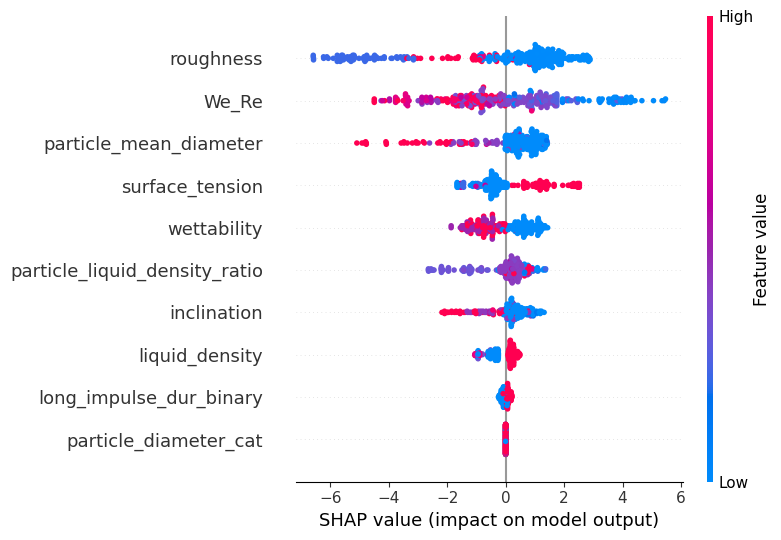

In [24]:
get_shap_interpretation(model, X_train)

# Модель на признаках из сообщения от 11 апреля в 10:09 в tg


Со Splashing и net_impact посложнее.

- По Re и We: возможны два датасета, в одном Re и We (два признака), в другом We_Re (один признак, либо ещё оставить We исходя из отсутствия мультиколлинеарности с We_Re)
- Второй важный признак тоже wettability_lyophobic
- Далее:
  - volume_fraction_binary, 
  - particle_liquid_density_ratio, 
  - particle_droplet_diameter_ratio (или particle_diameter_cat_large & _small),  
  - и возможно roughness_binary,

In [25]:
features = ['We', 'We_Re', 
'wettability_lyophobic', 'volume_fraction_binary', 
'particle_liquid_density_ratio', 'particle_droplet_diameter_ratio', 
'roughness_binary']

## Spalashing

In [26]:
cs = CreateSamples(df, train, test, features=features, target='splashing', dummies=True)
X_train, X_test, y_train, y_test = cs.get_samples()

In [27]:
model = XGBClassifier()
model.fit(X_train, y_train)
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
get_classification_report(y_train, y_test, y_preds, y_preds_proba)

,precision,recall,f1-score,support
0,0.833333,0.846154,0.839695,65.000000
1,0.824561,0.810345,0.817391,58.000000
accuracy,0.829268,0.829268,0.829268,0.829268
macro avg,0.828947,0.828249,0.828543,123.000000
weighted avg,0.829197,0.829268,0.829178,123.000000


In [28]:
get_cv_results(model, X_train, y_train, X_test, y_test)

F1 Train:	78.86% (std: 4.02%)
F1 Test:	70.23% (std: 5.12%)


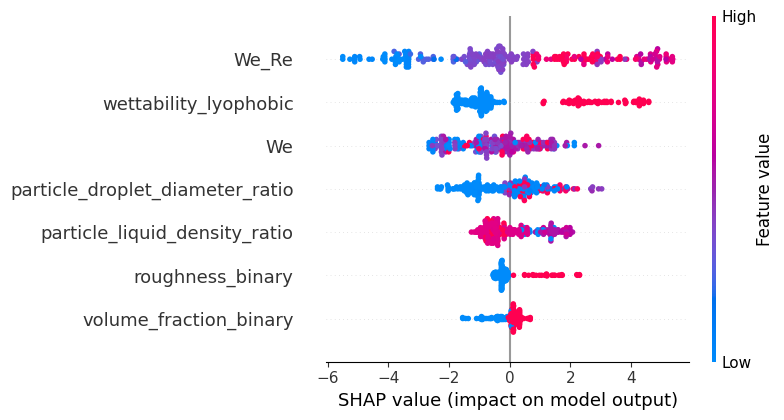

In [29]:
get_shap_interpretation(model, X_train)

## Net-impact

In [30]:
cs = CreateSamples(df, train, test, features=features, target='net_impact', dummies=True)
X_train, X_test, y_train, y_test = cs.get_samples()

In [31]:
model = XGBClassifier()
model.fit(X_train, y_train)
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
get_classification_report(y_train, y_test, y_preds, y_preds_proba)

,precision,recall,f1-score,support
0,0.879518,0.890244,0.884848,82.000000
1,0.775000,0.756098,0.765432,41.000000
accuracy,0.845528,0.845528,0.845528,0.845528
macro avg,0.827259,0.823171,0.825140,123.000000
weighted avg,0.844679,0.845528,0.845043,123.000000


In [32]:
get_cv_results(model, X_train, y_train, X_test, y_test)

F1 Train:	63.79% (std: 3.56%)
F1 Test:	62.84% (std: 14.14%)


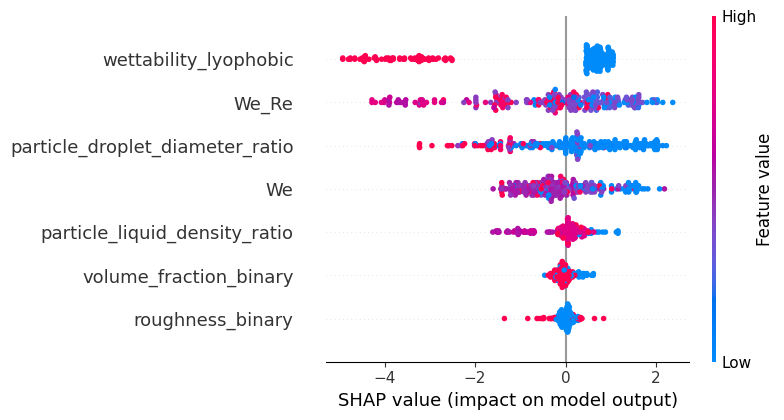

In [33]:
get_shap_interpretation(model, X_train)

# CatBoost на тех же признаках

## Spalashing

In [34]:
cs = CreateSamples(df, train, test, features=features, target='splashing', dummies=True)
X_train, X_test, y_train, y_test = cs.get_samples()

In [35]:
model = CatBoostClassifier(verbose=False)
model.fit(X_train, y_train)
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
get_classification_report(y_train, y_test, y_preds, y_preds_proba)

,precision,recall,f1-score,support
0,0.859375,0.846154,0.852713,65.000000
1,0.830508,0.844828,0.837607,58.000000
accuracy,0.845528,0.845528,0.845528,0.845528
macro avg,0.844942,0.845491,0.845160,123.000000
weighted avg,0.845763,0.845528,0.845590,123.000000


In [36]:
get_cv_results(model, X_train, y_train, X_test, y_test)

F1 Train:	81.30% (std: 5.14%)
F1 Test:	78.70% (std: 5.90%)


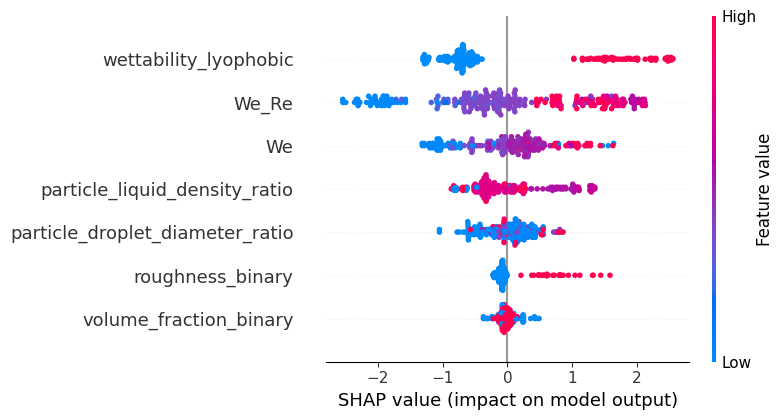

In [37]:
get_shap_interpretation(model, X_train)

## Net-impact

In [38]:
cs = CreateSamples(df, train, test, features=features, target='net_impact', dummies=True)
X_train, X_test, y_train, y_test = cs.get_samples()

In [39]:
model = CatBoostClassifier(verbose=False)
model.fit(X_train, y_train)
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
get_classification_report(y_train, y_test, y_preds, y_preds_proba)

,precision,recall,f1-score,support
0,0.863636,0.926829,0.894118,82.000000
1,0.828571,0.707317,0.763158,41.000000
accuracy,0.853659,0.853659,0.853659,0.853659
macro avg,0.846104,0.817073,0.828638,123.000000
weighted avg,0.851948,0.853659,0.850464,123.000000


In [40]:
get_cv_results(model, X_train, y_train, X_test, y_test)

F1 Train:	73.54% (std: 4.36%)
F1 Test:	67.93% (std: 13.25%)


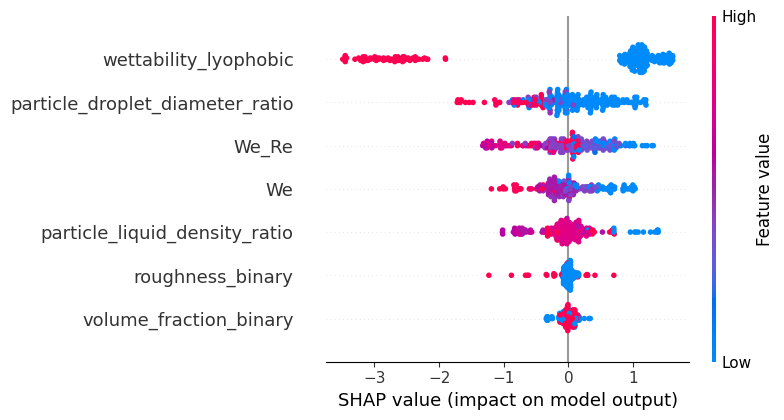

In [41]:
get_shap_interpretation(model, X_train)